In [3]:
import fastf1
import pandas
import matplotlib.pyplot as plt
import numpy as np

In [4]:
#tyres available: C3, C4, C5
#race duration: 58 laps (307.574km total distance)

#assumption of tyre pace delta per lap: 0.5s between each tyre
#C5 the fastest

#assumption of deg per lap: fuel corrected lap times increase
#linearly as tyre wears (linear tyre deg model assumed due to lack 
#of detailed info on compounds

#fuel correction assumption for 110kg of fuel to last 58 laps and 0.035s
#laptime gain per 1kg of fuel burn


In [7]:
# Constants
fuelQuantity = 110           # Total fuel in kg
totalLapNumber = 58          # Total number of laps
timePerKg = 0.035            # Time lost per kg of fuel in seconds

# Fuel consumption per lap
fuelConsumption = fuelQuantity / totalLapNumber  # kg consumed per lap

# List to store fuel correction per lap
fuelLapCorrections = []

# Loop through each lap to calculate fuel correction
for lap in range(1, totalLapNumber + 1):
    fuelCorrectionFactor = fuelConsumption * timePerKg
    fuelCorrectionForLap = fuelCorrectionFactor * (totalLapNumber - lap)
    fuelLapCorrections.append(fuelCorrectionForLap)

# Output: list of fuel corrections per lap
print(fuelLapCorrections)

[3.783620689655173, 3.7172413793103454, 3.650862068965518, 3.58448275862069, 3.5181034482758626, 3.451724137931035, 3.3853448275862075, 3.31896551724138, 3.2525862068965523, 3.1862068965517247, 3.1198275862068967, 3.053448275862069, 2.9870689655172415, 2.920689655172414, 2.8543103448275864, 2.787931034482759, 2.7215517241379312, 2.6551724137931036, 2.588793103448276, 2.5224137931034485, 2.456034482758621, 2.3896551724137933, 2.3232758620689657, 2.256896551724138, 2.1905172413793106, 2.124137931034483, 2.0577586206896554, 1.9913793103448278, 1.9250000000000003, 1.8586206896551727, 1.792241379310345, 1.7258620689655175, 1.65948275862069, 1.5931034482758624, 1.5267241379310346, 1.460344827586207, 1.3939655172413794, 1.3275862068965518, 1.2612068965517242, 1.1948275862068967, 1.128448275862069, 1.0620689655172415, 0.9956896551724139, 0.9293103448275863, 0.8629310344827588, 0.7965517241379312, 0.7301724137931035, 0.6637931034482759, 0.5974137931034483, 0.5310344827586208, 0.4646551724137931

In [29]:
# Constants for tyre wear factors
c5Wear = 0.260  # C4 wear in seconds per lap
c4Wear = 0.156    # C3 wear in seconds per lap
c3Wear = 0.110   # C2 wear in seconds per lap 

c5InitialLaptime = 79.7
c4InitialLaptime = 80.2
c3InitialLaptime = 80.7


# Assuming total laps in the race
totalLapNumber = 58

# Starting with fresh tires (lap 1)
tyreAge = list(range(1, totalLapNumber + 1))

# Fuel correction per lap (as previously calculated)
fuelQuantity = 110           # Total fuel in kg
timePerKg = 0.035            # Time lost per kg of fuel in seconds
fuelConsumption = fuelQuantity / totalLapNumber

# Lists to store lap times
c5LapTimes = []
c4LapTimes = []
c3LapTimes = []

# Loop through each lap and calculate lap times with tire degradation
for lap in range(1, totalLapNumber + 1):
    # Tire degradation for each compound
    c5TyreDegLaptime = c5InitialLaptime + (c5Wear * np.exp(0.13 * (lap - 1)))
    c4TyreDegLaptime = c4InitialLaptime + (c4Wear * np.exp(0.0975 *(lap - 1)))
    c3TyreDegLaptime = c3InitialLaptime + (c3Wear * np.exp(0.0875 *(lap - 1)))
    
    # Append the lap times to their respective lists
    c5LapTimes.append(c5TyreDegLaptime)
    c4LapTimes.append(c4TyreDegLaptime)
    c3LapTimes.append(c3TyreDegLaptime)

# Output the lap times for the first few laps to check
print("C5 Lap Times:", c5LapTimes[:5])  # Print first 5 laps for C5 compound
print("C4 Lap Times:", c4LapTimes[:5])  # Print first 5 laps for C4 compound
print("C3 Lap Times:", c3LapTimes[:5])  # Print first 5 laps for C3 compound

C5 Lap Times: [79.96000000000001, 79.99609537966441, 80.0372018225331, 80.08401500640949, 80.13732718892172]
C4 Lap Times: [80.35600000000001, 80.37197618488388, 80.3895885138924, 80.40900454690397, 80.4304090038457]
C3 Lap Times: [80.81, 80.82005864908872, 80.83103708382737, 80.84301941149853, 80.85609743034526]


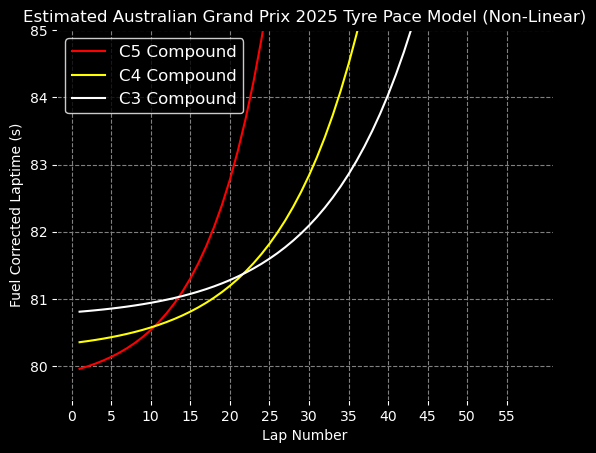

In [31]:
lapNumber = range(1, totalLapNumber + 1)  # List of lap numbers
# Use the previously calculated lap times for C4, C3, and C2 compounds
# (these should be lists of lap times for each lap)
# For example:
# c4LapTimes = [102.0, 102.115, 102.23, ...] 
# c3LapTimes = [102.5, 102.6, 102.7, ...] 
# c2LapTimes = [103.0, 103.09, 103.18, ...]

# Create a figure with a black background
fig, ax = plt.subplots()
fig.patch.set_facecolor('black')  # Set the figure background color to black
ax.set_facecolor('black')         # Set the axes background color to black


# Plot the lap times for each compound
plt.plot(lapNumber, c5LapTimes, label="C5 Compound",color="red")
plt.plot(lapNumber, c4LapTimes, label="C4 Compound",color="yellow")
plt.plot(lapNumber, c3LapTimes, label="C3 Compound",color="white")

# Add title and labels
plt.title("Estimated Australian Grand Prix 2025 Tyre Pace Model (Non-Linear)",color="white")
plt.xlabel("Lap Number",color="white")
plt.ylabel("Fuel Corrected Laptime (s)",color="white")
plt.ylim(79.5,85)
plt.xticks(np.arange(0, totalLapNumber + 1, 5))

# Customize tick colors for visibility
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

# Set grid color and style (optional)
ax.grid(True, color="gray", linestyle="--")

# Show the legend with a white font color
plt.legend(facecolor="black", edgecolor="white", fontsize='large', labelcolor='white')

# Display the plot
plt.show()